In [304]:
from gnncloudmanufacturing.data import read_fatahi_dataset
from gnncloudmanufacturing.dp_solver import dp_solve
from gnncloudmanufacturing.greedy_solver import greedy_solve
from gnncloudmanufacturing.gnn_solver import gnn_solve
from gnncloudmanufacturing.random_solver import random_solve
from gnncloudmanufacturing.validation import total_cost_from_gamma
from gnncloudmanufacturing.utils import delta_from_gamma
from gnncloudmanufacturing.visualization import plot_problem, plot_solution

from copy import deepcopy

  0%|          | 0/18 [00:00<?, ?it/s]

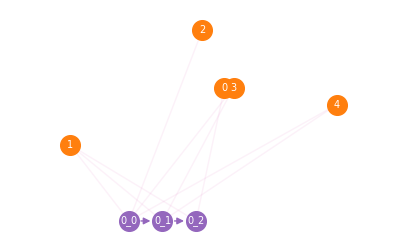

5,5,5-1


In [329]:
fatahi_dataset = read_fatahi_dataset('../../data/fatahi.xlsx')
_problem = fatahi_dataset[15]
name = _problem['name']
_problem['n_tasks'] = 1
_problem['operation'] = _problem['operation'][:, [1]]
plot_problem(_problem, figsize=(5,3))
print(name)

526.4191084555065


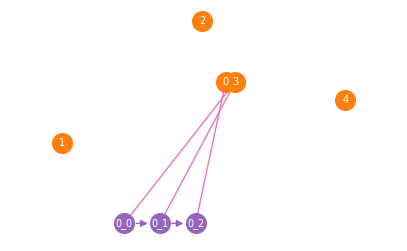

In [377]:
problem = deepcopy(_problem)

gamma = dp_solve(problem)
delta = delta_from_gamma(problem, gamma)
print(total_cost_from_gamma(problem, gamma, delta))
plot_solution(problem, gamma, figsize=(5, 3))

526.4191084555065


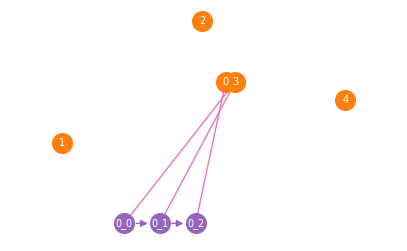

In [378]:
gamma = gnn_solve(
    problem, 
    path_to_ckpt='gnn-5-5-5.ckpt', 
    n_operations=5, 
    out_dim=16, 
    n_layers=1, 
    n_iterations=1,
)
delta = delta_from_gamma(problem, gamma)
print(total_cost_from_gamma(problem, gamma, delta))
plot_solution(problem, gamma, figsize=(5, 3))

In [379]:
problem = deepcopy(_problem)
print(problem['op_cost'][[0, 1], 3])
problem['op_cost'][[0, 1], 3] = problem['op_cost'][[0, 1], 3] * 100
print(total_cost_from_gamma(problem, gamma, delta))

[29.9320437  49.52328978]
37863.83332022555


605.2593167377831


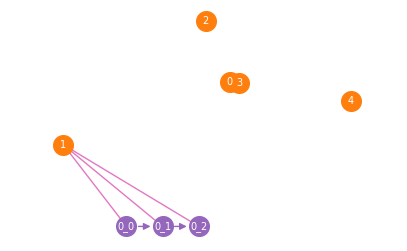

In [380]:
gamma = dp_solve(problem)
delta = delta_from_gamma(problem, gamma)
print(total_cost_from_gamma(problem, gamma, delta))
plot_solution(problem, gamma, figsize=(5, 3))

857.9087012896454


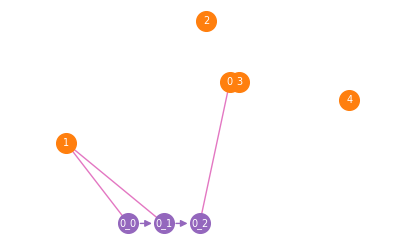

In [408]:
gamma = gnn_solve(
    problem, 
    path_to_ckpt='gnn-5-5-5.ckpt', 
    n_operations=5, 
    out_dim=16, 
    n_layers=1,
    n_iterations=30,
)
delta = delta_from_gamma(problem, gamma)
print(total_cost_from_gamma(problem, gamma, delta))
plot_solution(problem, gamma, figsize=(5, 3))